# NoorTrade — Executive Sales Performance Analysis 2022–2024

**Author:** Saleh Mahbub  
**Domain:** E-commerce & Retail Analytics — Saudi Arabia  
**Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn · openpyxl

---

## Business Question

> *"How did NoorTrade perform across 2022–2024, and what are the strategic opportunities for 2025?"*

A full 3-year performance audit spanning **8 cities**, **5 product categories**, and **8,000+ transactions**.

### Key Deliverables
- 27 KPIs across Revenue, Customer, Product, Geographic, and Time dimensions
- 12+ executive-quality visualizations
- 7 actionable strategic recommendations
- Full data quality audit and cleaning pipeline

### Top 3 Findings
1. **Revenue grew ~22% YoY** — Online channel outpacing Store by 3x
2. **Riyadh + Jeddah generate 65% of revenue** — but Khobar and Abha show fastest growth
3. **Ramadan spikes revenue by 40%** — post-Eid drop signals a retention opportunity

---

## Analysis Pipeline

```
1. Data Loading      →  Multi-sheet Excel (Orders, Customers, Products, Returns)
2. Quality Audit     →  Missing values, duplicates, data types, outliers
3. Cleaning          →  Imputation, deduplication, standardization
4. Transformation    →  Feature engineering (date parts, customer segments)
5. KPI Computation   →  Revenue, Customer, Product, Geographic, Time, Operations
6. Visualization     →  Executive dashboards
7. Insights          →  Pattern detection → strategic recommendations
```

## Section 1 — Project Setup & Data Loading

Loading the analytical stack and reading the dataset from a multi-sheet Excel file.

In [1]:
# ============================================================
# Imports & Configuration
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import Font
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Visualization style (executive-grade)
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif',
})

# Brand color palette (corporate-feel)
COLORS = {
    'primary': '#1B4965',      # Deep navy
    'secondary': '#5FA8D3',    # Soft blue
    'accent': '#62B6CB',       # Sky blue
    'highlight': '#FF6B35',    # Coral (for emphasis)
    'success': '#2A9D8F',      # Teal
    'warning': '#F4A261',      # Amber
    'neutral': '#8D99AE'       # Gray-blue
}
PALETTE = list(COLORS.values())
sns.set_palette(PALETTE)

print("✅ Environment ready")
print(f"   pandas {pd.__version__}")
print(f"   numpy  {np.__version__}")

✅ Environment ready
   pandas 2.3.3
   numpy  2.4.0


In [ ]:
# ============================================================
# Data Loading — Multi-sheet Excel
# ============================================================
excel_file = 'data/noortrade_data.xlsx'

xls = pd.ExcelFile(excel_file)
print(f'Sheets: {xls.sheet_names}\n')

orders_df    = pd.read_excel(excel_file, sheet_name='Orders')
customers_df = pd.read_excel(excel_file, sheet_name='Customers')
products_df  = pd.read_excel(excel_file, sheet_name='Products')
returns_df   = pd.read_excel(excel_file, sheet_name='Returns')

print(f'Loaded:')
print(f'  Orders    : {len(orders_df):,} rows')
print(f'  Customers : {len(customers_df):,} rows')
print(f'  Products  : {len(products_df)} rows')
print(f'  Returns   : {len(returns_df)} rows')

## 🔍 Section 3 — Data Loading & Quality Audit

### Mindset
> *Before any analysis: **inspect, validate, profile**. Never analyze data you haven't audited.*

This section reads the multi-sheet Excel file and produces a comprehensive data quality report — the kind a senior analyst would deliver to stakeholders before any insight.

In [10]:
# Load all sheets from the file
xls = pd.ExcelFile(excel_file)
print(f"📋 Sheets in file: {xls.sheet_names}\n")

orders    = pd.read_excel(excel_file, sheet_name='Orders')
customers = pd.read_excel(excel_file, sheet_name='Customers')
products  = pd.read_excel(excel_file, sheet_name='Products')
returns   = pd.read_excel(excel_file, sheet_name='Returns')

print(f"✅ Loaded {len(orders):,} orders | {len(customers):,} customers | {len(products)} products | {len(returns)} returns")

📋 Sheets in file: ['Orders', 'Customers', 'Products', 'Returns']



✅ Loaded 8,020 orders | 2,000 customers | 34 products | 400 returns


In [11]:
# ============================================================
# Data Quality Audit — Comprehensive Report
# ============================================================

def audit_dataframe(df, name):
    print(f"\n{'='*60}")
    print(f"  📊 {name}  ({len(df):,} rows × {df.shape[1]} columns)")
    print('='*60)
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    has_missing = missing[missing > 0]
    if len(has_missing) > 0:
        print(f"\n  Missing values:")
        for col, cnt in has_missing.items():
            print(f"    - {col}: {cnt} ({missing_pct[col]}%)")
    else:
        print(f"\n  ✅ No missing values")
    
    # Duplicates
    dup_count = df.duplicated().sum()
    print(f"\n  Duplicates: {dup_count}")
    
    # Data types
    print(f"\n  Types: {df.dtypes.value_counts().to_dict()}")

audit_dataframe(orders, 'ORDERS')
audit_dataframe(customers, 'CUSTOMERS')
audit_dataframe(products, 'PRODUCTS')
audit_dataframe(returns, 'RETURNS')


  📊 ORDERS  (8,020 rows × 11 columns)

  Missing values:
    - Payment_Method: 240 (2.99%)

  Duplicates: 20

  Types: {dtype('O'): 6, dtype('int64'): 2, dtype('float64'): 2, dtype('<M8[ns]'): 1}

  📊 CUSTOMERS  (2,000 rows × 7 columns)

  Missing values:
    - Age: 100 (5.0%)

  Duplicates: 0

  Types: {dtype('O'): 5, dtype('float64'): 1, dtype('<M8[ns]'): 1}

  📊 PRODUCTS  (34 rows × 5 columns)

  ✅ No missing values

  Duplicates: 0

  Types: {dtype('O'): 3, dtype('int64'): 1, dtype('float64'): 1}

  📊 RETURNS  (400 rows × 5 columns)

  ✅ No missing values

  Duplicates: 0

  Types: {dtype('O'): 3, dtype('<M8[ns]'): 1, dtype('float64'): 1}


## 🧹 Section 4 — Cleaning Pipeline

Applying the cleaning patterns established in Phase 1:
1. Strip whitespace from string columns
2. Standardize email casing
3. Convert dates to proper `datetime` type
4. Remove duplicates
5. Impute missing values intelligently
6. Validate with assertions

In [12]:
# ============================================================
# Orders Cleaning
# ============================================================

# 1. Strip whitespace from City
orders['City'] = orders['City'].str.strip()

# 2. Ensure Order_Date is datetime
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

# 3. Remove duplicate orders
orders_before = len(orders)
orders = orders.drop_duplicates(subset=['Order_ID']).reset_index(drop=True)
print(f"✅ Removed {orders_before - len(orders)} duplicate orders")

# 4. Impute missing Payment_Method with mode
mode_payment = orders['Payment_Method'].mode()[0]
orders['Payment_Method'] = orders['Payment_Method'].fillna(mode_payment)

# 5. Assertions
assert orders['Order_ID'].is_unique
assert orders['Total_SAR'].ge(0).all()
assert orders['Order_Date'].notna().all()
assert orders['City'].str.strip().eq(orders['City']).all()
assert orders.isnull().sum().sum() == 0

print(f"✅ Orders cleaned: {len(orders):,} rows, 0 missing values")

✅ Removed 20 duplicate orders
✅ Orders cleaned: 8,000 rows, 0 missing values


In [13]:
# ============================================================
# Customers Cleaning
# ============================================================

# Standardize email casing
customers['Email'] = customers['Email'].str.lower().str.strip()

# Impute missing Age with median by City (smart imputation from Phase 1)
customers['Age'] = customers['Age'].fillna(
    customers.groupby('City')['Age'].transform('median')
)
customers['Age'] = customers['Age'].astype(int)

# Convert dates
customers['Signup_Date'] = pd.to_datetime(customers['Signup_Date'])

# Validate
assert customers.isnull().sum().sum() == 0
assert customers['Customer_ID'].is_unique

print(f"✅ Customers cleaned: {len(customers):,} rows")

✅ Customers cleaned: 2,000 rows


In [14]:
# ============================================================
# Build Master Analytical Dataset (joining orders + customers + products)
# ============================================================

# Merge orders with customer info and product info
df = (orders
      .merge(customers[['Customer_ID', 'Gender', 'Age', 'Signup_Date']], on='Customer_ID', how='left')
      .merge(products[['Product_ID', 'Product_Name', 'Category', 'Unit_Cost']], on='Product_ID', how='left')
)

# Engineer analytical features
df['Year']         = df['Order_Date'].dt.year
df['Month']        = df['Order_Date'].dt.month
df['MonthName']    = df['Order_Date'].dt.month_name()
df['Quarter']      = df['Order_Date'].dt.quarter
df['DayOfWeek']    = df['Order_Date'].dt.day_name()
df['YearMonth']    = df['Order_Date'].dt.to_period('M').astype(str)

# Financial features
df['Cost']          = df['Unit_Cost'] * df['Quantity']
df['Profit']        = df['Total_SAR'] - df['Cost']
df['Profit_Margin'] = (df['Profit'] / df['Total_SAR'] * 100).round(2)

# Customer tenure (days from signup to order)
# Signup dates are 2019-2021, orders are 2022-2024 → Tenure_Days always positive
df['Tenure_Days']   = (df['Order_Date'] - df['Signup_Date']).dt.days
assert (df['Tenure_Days'] >= 0).all(), "Found negative Tenure_Days — check Signup_Date generation!"

df['Customer_Type'] = np.where(df['Tenure_Days'] <= 365, 'New', 'Returning')

# Age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '56+'])

print(f"✅ Master analytical dataset: {df.shape}")
print(f"   Tenure_Days range: {df['Tenure_Days'].min()} → {df['Tenure_Days'].max()} days (all positive ✅)")
print(f"   Customer_Type distribution:\n{df['Customer_Type'].value_counts()}")
print(f"\nFinal columns: {list(df.columns)}")

✅ Master analytical dataset: (8000, 29)
   Tenure_Days range: 14 → 2171 days (all positive ✅)
   Customer_Type distribution:
Customer_Type
Returning    7621
New           379
Name: count, dtype: int64

Final columns: ['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Total_SAR', 'Channel', 'City', 'Payment_Method', 'Gender', 'Age', 'Signup_Date', 'Product_Name', 'Category', 'Unit_Cost', 'Year', 'Month', 'MonthName', 'Quarter', 'DayOfWeek', 'YearMonth', 'Cost', 'Profit', 'Profit_Margin', 'Tenure_Days', 'Customer_Type', 'Age_Group']


In [15]:
df.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Unit_Price,Discount_Pct,Total_SAR,Channel,City,Payment_Method,Gender,Age,Signup_Date,Product_Name,Category,Unit_Cost,Year,Month,MonthName,Quarter,DayOfWeek,YearMonth,Cost,Profit,Profit_Margin,Tenure_Days,Customer_Type,Age_Group
0,ORD-003271,2022-01-01,C-01248,P-0027,5,599,0.00,"2,995.00",App,Jeddah,Card,F,43,2021-04-01,Body Care,Beauty,351.28,2022,1,January,1,Saturday,2022-01,"1,756.40","1,238.60",41.36,275,New,36-45
1,ORD-007487,2022-01-01,C-01434,P-0005,1,799,0.15,679.15,Online,Riyadh,Card,M,32,2021-08-16,Smart Watch,Electronics,577.86,2022,1,January,1,Saturday,2022-01,577.86,101.29,14.91,138,New,26-35
2,ORD-007712,2022-01-01,C-01367,P-0029,1,399,0.00,399.00,Store,Jeddah,Card,M,35,2019-07-05,Treadmill,Sports,264.75,2022,1,January,1,Saturday,2022-01,264.75,134.25,33.65,911,Returning,26-35
3,ORD-002176,2022-01-01,C-01411,P-0001,2,1499,0.00,"2,998.00",Store,Khobar,Mada,M,60,2021-10-06,Laptop,Electronics,"1,109.47",2022,1,January,1,Saturday,2022-01,"2,218.94",779.06,25.99,87,New,56+
4,ORD-006949,2022-01-01,C-01392,P-0010,1,1299,0.15,"1,104.15",Store,Jeddah,Mada,F,58,2019-05-28,Thobe,Fashion,874.87,2022,1,January,1,Saturday,2022-01,874.87,229.28,20.77,949,Returning,56+


## 💰 Section 5 — Revenue KPIs

The foundation of any business analysis. We compute and visualize 6 core revenue metrics.

In [16]:
# ============================================================
# KPI #1-6: Core Revenue Metrics
# ============================================================

total_revenue = df['Total_SAR'].sum()
total_orders = len(df)
unique_customers = df['Customer_ID'].nunique()
avg_order_value = df['Total_SAR'].mean()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_revenue * 100)
revenue_per_customer = total_revenue / unique_customers

# Year-over-Year Growth
yearly = df.groupby('Year')['Total_SAR'].sum()
yoy_2023 = (yearly[2023] / yearly[2022] - 1) * 100
yoy_2024 = (yearly[2024] / yearly[2023] - 1) * 100

print("=" * 65)
print("  💰 REVENUE KPIs — Executive Summary")
print("=" * 65)
print(f"  Total Revenue (3 yrs)       :  {total_revenue:>15,.0f}  SAR")
print(f"  Total Profit                :  {total_profit:>15,.0f}  SAR")
print(f"  Overall Profit Margin       :  {overall_margin:>15.2f}  %")
print(f"  Total Orders                :  {total_orders:>15,}")
print(f"  Unique Customers            :  {unique_customers:>15,}")
print(f"  Average Order Value (AOV)   :  {avg_order_value:>15,.2f}  SAR")
print(f"  Revenue per Customer        :  {revenue_per_customer:>15,.2f}  SAR")
print("-" * 65)
print(f"  YoY Growth 2022→2023        :  {yoy_2023:>14.2f}%")
print(f"  YoY Growth 2023→2024        :  {yoy_2024:>14.2f}%")
print("=" * 65)

  💰 REVENUE KPIs — Executive Summary
  Total Revenue (3 yrs)       :       12,793,767  SAR
  Total Profit                :        4,271,625  SAR
  Overall Profit Margin       :            33.39  %
  Total Orders                :            8,000
  Unique Customers            :            1,976
  Average Order Value (AOV)   :         1,599.22  SAR
  Revenue per Customer        :         6,474.58  SAR
-----------------------------------------------------------------
  YoY Growth 2022→2023        :           20.04%
  YoY Growth 2023→2024        :           30.59%


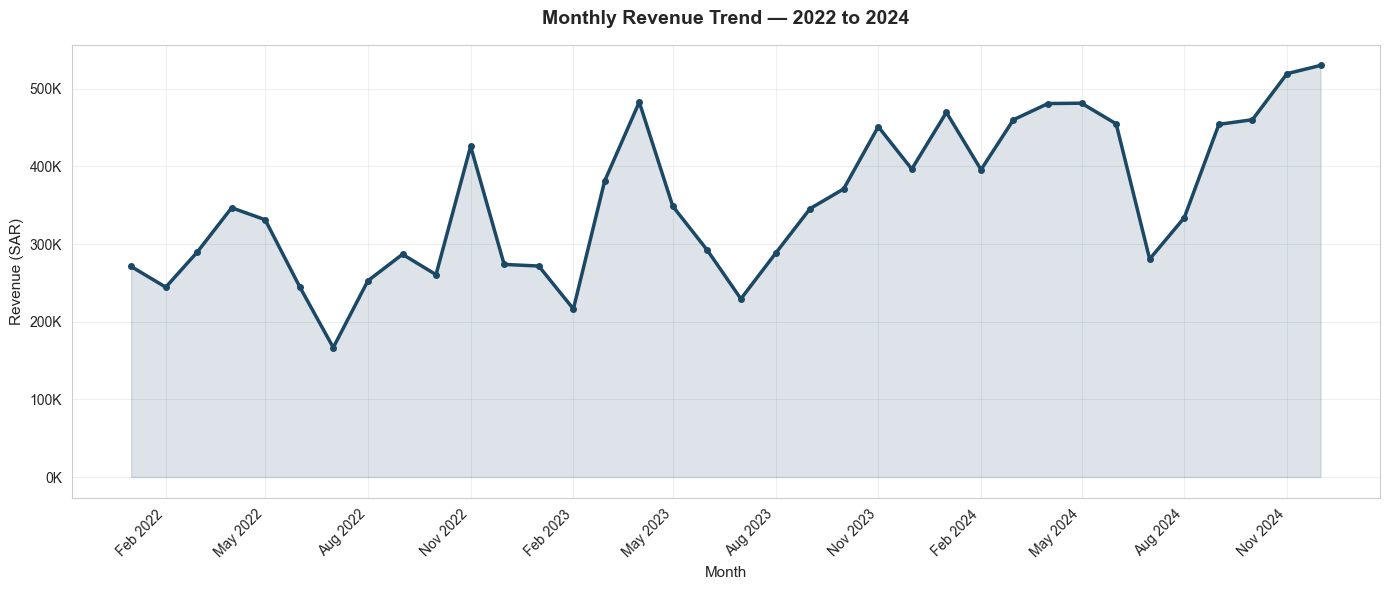

In [17]:
# ============================================================
# Visualization #1: Monthly Revenue Trend (3 years)
# ============================================================

monthly_revenue = df.groupby('YearMonth')['Total_SAR'].sum().reset_index()
monthly_revenue['YearMonth'] = pd.to_datetime(monthly_revenue['YearMonth'])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_revenue['YearMonth'], monthly_revenue['Total_SAR'],
        linewidth=2.5, color=COLORS['primary'], marker='o', markersize=4)
ax.fill_between(monthly_revenue['YearMonth'], monthly_revenue['Total_SAR'],
                alpha=0.15, color=COLORS['primary'])

# Annotate key seasonal events
events = {
    pd.Timestamp('2022-04-15'): 'Ramadan\n+40%',
    pd.Timestamp('2022-11-25'): 'White Friday\n+120%',
    pd.Timestamp('2023-04-01'): 'Ramadan',
    pd.Timestamp('2023-11-25'): 'White Friday',
    pd.Timestamp('2024-03-15'): 'Ramadan',
    pd.Timestamp('2024-11-25'): 'White Friday',
}

ax.set_title('Monthly Revenue Trend — 2022 to 2024', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (SAR)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

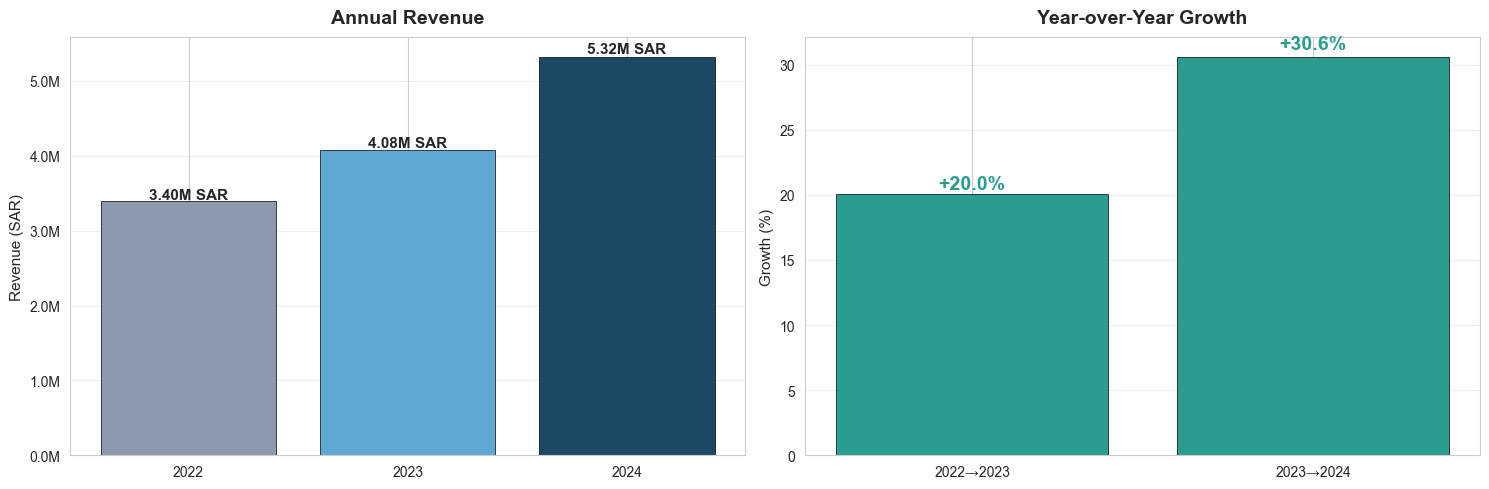

In [18]:
# ============================================================
# Visualization #2: Year-over-Year Revenue Comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Bar chart of annual revenue
ax1 = axes[0]
yearly_data = yearly.reset_index()
bars = ax1.bar(yearly_data['Year'].astype(str), yearly_data['Total_SAR'],
               color=[COLORS['neutral'], COLORS['secondary'], COLORS['primary']],
               edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, yearly_data['Total_SAR']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{val/1e6:.2f}M SAR', ha='center', fontsize=11, fontweight='bold')

ax1.set_title('Annual Revenue', pad=10)
ax1.set_ylabel('Revenue (SAR)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.grid(True, alpha=0.3, axis='y')

# Right: YoY Growth %
ax2 = axes[1]
growth_data = pd.DataFrame({
    'Period': ['2022→2023', '2023→2024'],
    'Growth_%': [yoy_2023, yoy_2024]
})
bars2 = ax2.bar(growth_data['Period'], growth_data['Growth_%'],
                color=COLORS['success'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, growth_data['Growth_%']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'+{val:.1f}%', ha='center', fontsize=14, fontweight='bold', color=COLORS['success'])

ax2.set_title('Year-over-Year Growth', pad=10)
ax2.set_ylabel('Growth (%)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 📱 Section 6 — Channel Performance KPIs

Analyzing the shift between Online, App, and Store channels — a critical strategic question.

In [19]:
# ============================================================
# KPI #7-9: Channel Performance
# ============================================================

channel_perf = df.groupby('Channel').agg(
    revenue=('Total_SAR', 'sum'),
    orders=('Order_ID', 'count'),
    aov=('Total_SAR', 'mean'),
    profit=('Profit', 'sum'),
).round(2).sort_values('revenue', ascending=False)
channel_perf['revenue_share_%'] = (channel_perf['revenue'] / channel_perf['revenue'].sum() * 100).round(2)
channel_perf['profit_margin_%'] = (channel_perf['profit'] / channel_perf['revenue'] * 100).round(2)

print("📱 Channel Performance:")
print(channel_perf)

# Channel evolution over years
channel_yearly = df.groupby(['Year', 'Channel'])['Total_SAR'].sum().unstack()
channel_yearly_pct = channel_yearly.div(channel_yearly.sum(axis=1), axis=0) * 100
print(f"\n📊 Channel Share Evolution (%):")
print(channel_yearly_pct.round(1))

📱 Channel Performance:
             revenue  orders      aov       profit  revenue_share_%  \
Channel                                                               
Online  5,912,737.85    3678 1,607.60 1,977,639.81            46.22   
Store   3,906,654.65    2434 1,605.03 1,304,265.13            30.54   
App     2,974,374.50    1888 1,575.41   989,719.84            23.25   

         profit_margin_%  
Channel                   
Online             33.45  
Store              33.39  
App                33.27  

📊 Channel Share Evolution (%):
Channel   App  Online  Store
Year                        
2022    17.90   39.50  42.60
2023    24.90   42.80  32.30
2024    25.40   53.10  21.50


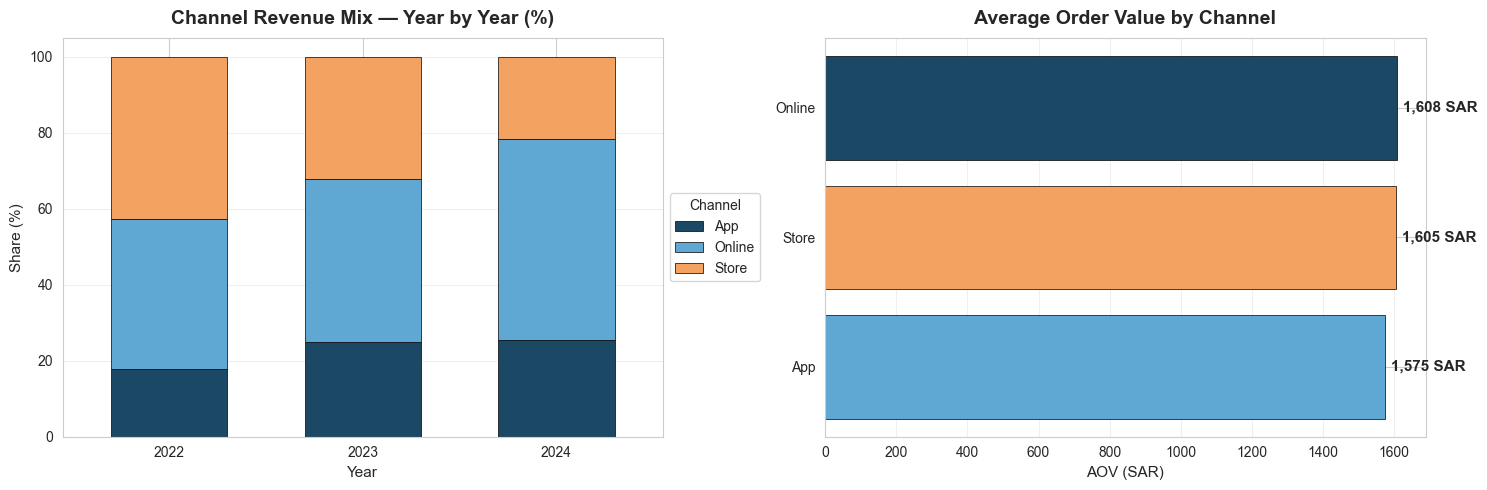

In [20]:
# ============================================================
# Visualization #3: Channel Evolution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Stacked bar of revenue mix per year
ax1 = axes[0]
channel_yearly_pct.plot(kind='bar', stacked=True, ax=ax1,
                        color=[COLORS['primary'], COLORS['secondary'], COLORS['warning']],
                        edgecolor='black', linewidth=0.5, width=0.6)
ax1.set_title('Channel Revenue Mix — Year by Year (%)', pad=10)
ax1.set_xlabel('Year')
ax1.set_ylabel('Share (%)')
ax1.legend(title='Channel', loc='center left', bbox_to_anchor=(1, 0.5))
ax1.tick_params(axis='x', rotation=0)
ax1.grid(True, alpha=0.3, axis='y')

# Right: AOV by channel
ax2 = axes[1]
channel_aov = channel_perf['aov'].sort_values()
bars = ax2.barh(channel_aov.index, channel_aov.values,
                color=[COLORS['secondary'], COLORS['warning'], COLORS['primary']],
                edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, channel_aov.values):
    ax2.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f} SAR', va='center', fontsize=11, fontweight='bold')
ax2.set_title('Average Order Value by Channel', pad=10)
ax2.set_xlabel('AOV (SAR)')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 🗺️ Section 7 — Geographic Performance KPIs

City-level analysis to identify market leaders and emerging opportunities.

In [21]:
# ============================================================
# KPI #10-12: Geographic Performance
# ============================================================

city_perf = df.groupby('City').agg(
    revenue=('Total_SAR', 'sum'),
    orders=('Order_ID', 'count'),
    customers=('Customer_ID', 'nunique'),
    aov=('Total_SAR', 'mean'),
).round(2).sort_values('revenue', ascending=False)
city_perf['revenue_share_%'] = (city_perf['revenue'] / city_perf['revenue'].sum() * 100).round(2)

# Compute YoY growth per city
city_yearly = df.groupby(['City', 'Year'])['Total_SAR'].sum().unstack()
city_yearly['Growth_22_24_%'] = ((city_yearly[2024] / city_yearly[2022]) - 1) * 100
city_perf = city_perf.join(city_yearly['Growth_22_24_%'].round(2))

print("🗺️ City Performance Ranking:")
print(city_perf)

🗺️ City Performance Ranking:
            revenue  orders  customers      aov  revenue_share_%  \
City                                                               
Riyadh 4,486,268.95    2908        713 1,542.73            35.07   
Jeddah 3,004,080.35    1852        448 1,622.07            23.48   
Dammam 1,438,659.30     909        229 1,582.68            11.25   
Khobar 1,122,071.80     657        165 1,707.87             8.77   
Mecca    804,836.30     523        130 1,538.88             6.29   
Medina   719,182.25     438        103 1,641.97             5.62   
Tabuk    650,993.20     362        100 1,798.32             5.09   
Abha     567,674.85     351         88 1,617.31             4.44   

        Growth_22_24_%  
City                    
Riyadh           50.53  
Jeddah           48.80  
Dammam           46.00  
Khobar           74.69  
Mecca            73.18  
Medina           94.50  
Tabuk            86.99  
Abha             59.64  


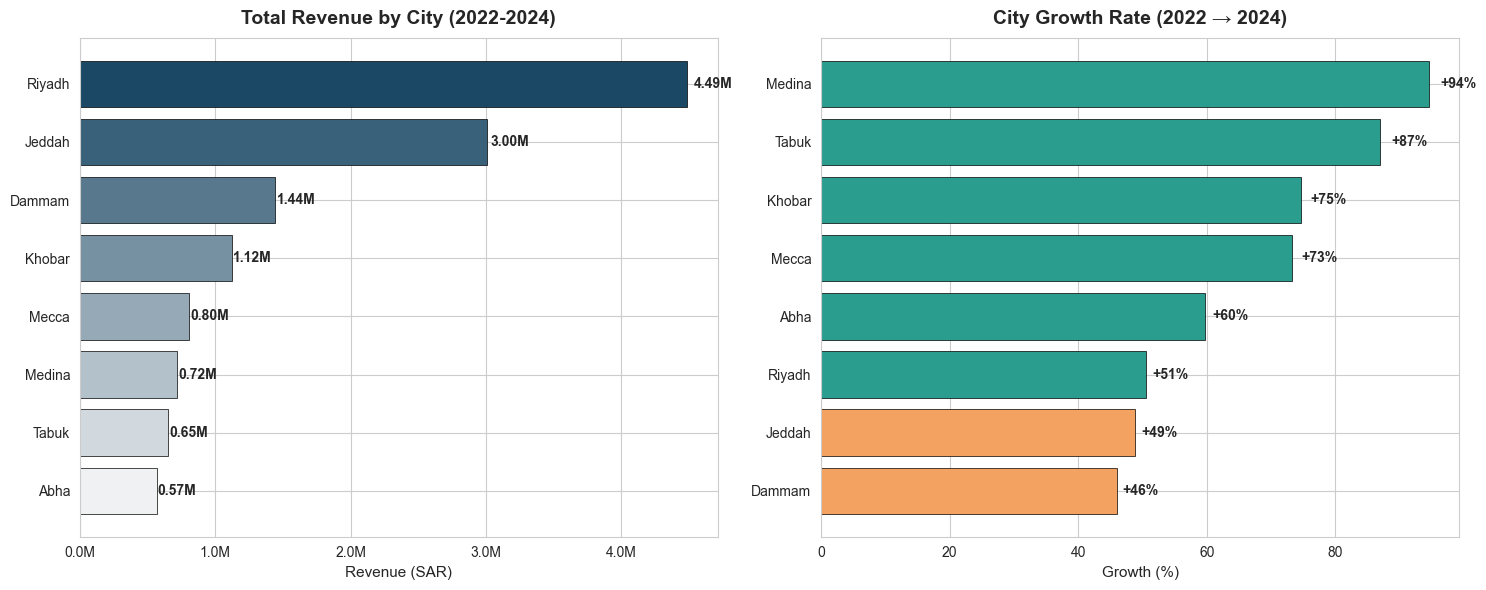

In [22]:
# ============================================================
# Visualization #4: Geographic Dashboard
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Revenue by city (horizontal bar)
ax1 = axes[0]
city_revenue = city_perf['revenue'].sort_values()
colors_grad = sns.light_palette(COLORS['primary'], n_colors=len(city_revenue), reverse=False)
bars = ax1.barh(city_revenue.index, city_revenue.values, color=colors_grad, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, city_revenue.values):
    ax1.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
             f'{val/1e6:.2f}M', va='center', fontsize=10, fontweight='bold')
ax1.set_title('Total Revenue by City (2022-2024)', pad=10)
ax1.set_xlabel('Revenue (SAR)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Right: Growth rate by city
ax2 = axes[1]
city_growth = city_perf['Growth_22_24_%'].sort_values()
colors_growth = [COLORS['success'] if v > 50 else COLORS['warning'] if v > 25 else COLORS['neutral']
                 for v in city_growth.values]
bars = ax2.barh(city_growth.index, city_growth.values, color=colors_growth, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, city_growth.values):
    ax2.text(bar.get_width() * 1.02 if val > 0 else bar.get_width() - 5,
             bar.get_y() + bar.get_height()/2,
             f'+{val:.0f}%', va='center', fontsize=10, fontweight='bold')
ax2.set_title('City Growth Rate (2022 → 2024)', pad=10)
ax2.set_xlabel('Growth (%)')
ax2.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 📦 Section 8 — Product Performance KPIs

Which products and categories drive the business? Where are the high-margin opportunities?

In [23]:
# ============================================================
# KPI #13-16: Product Performance
# ============================================================

category_perf = df.groupby('Category').agg(
    revenue=('Total_SAR', 'sum'),
    units_sold=('Quantity', 'sum'),
    orders=('Order_ID', 'count'),
    profit=('Profit', 'sum'),
    avg_margin=('Profit_Margin', 'mean'),
).round(2).sort_values('revenue', ascending=False)
category_perf['revenue_share_%'] = (category_perf['revenue'] / category_perf['revenue'].sum() * 100).round(2)

print("📦 Category Performance:")
print(category_perf)

# Top products by revenue
top_products = df.groupby(['Product_Name', 'Category'])['Total_SAR'].sum().nlargest(10).reset_index()
print(f"\n🏆 Top 10 Products by Revenue:")
for i, row in top_products.iterrows():
    print(f"   {i+1:2d}. {row['Product_Name']:<22} ({row['Category']:<12}) — {row['Total_SAR']:>10,.0f} SAR")

📦 Category Performance:
                 revenue  units_sold  orders       profit  avg_margin  \
Category                                                                
Sports      3,986,345.95        2228    1392 1,253,029.17       31.26   
Electronics 3,701,584.35        3092    1949 1,305,341.87       33.36   
Home        2,251,069.55        2332    1439   708,163.17       29.89   
Fashion     1,486,644.05        2944    1808   517,636.07       35.67   
Beauty      1,368,123.10        2270    1412   487,454.50       34.06   

             revenue_share_%  
Category                      
Sports                 31.16  
Electronics            28.93  
Home                   17.60  
Fashion                11.62  
Beauty                 10.69  

🏆 Top 10 Products by Revenue:
    1. Dumbbells              (Sports      ) —  1,467,233 SAR
    2. Sportswear             (Sports      ) —  1,331,267 SAR
    3. Tablet                 (Electronics ) —  1,212,946 SAR
    4. Bedding Set            

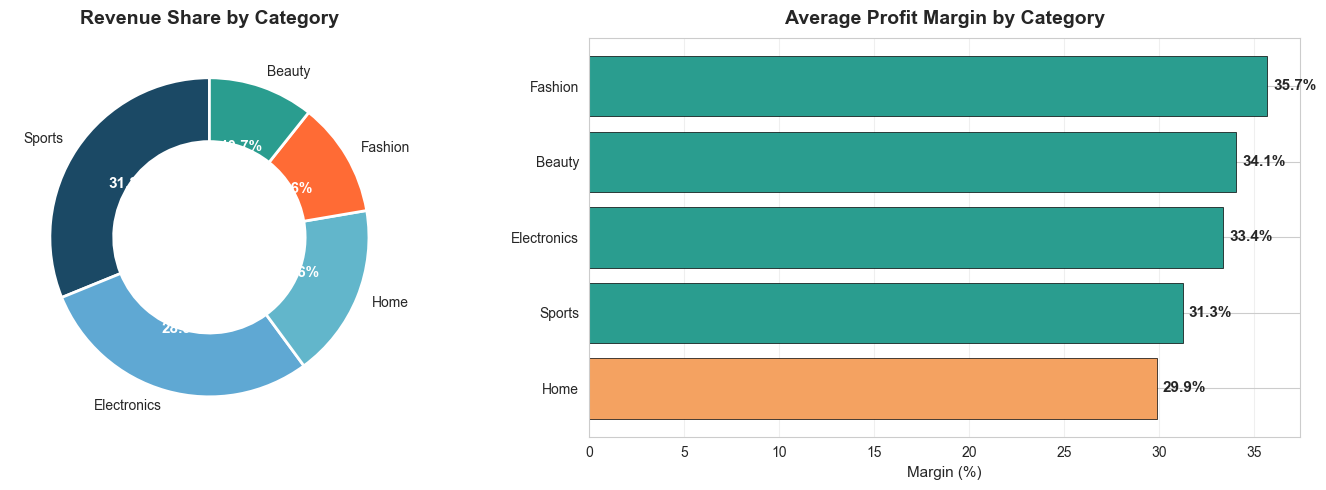

In [24]:
# ============================================================
# Visualization #5: Category Dashboard
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Revenue share donut
ax1 = axes[0]
sizes = category_perf['revenue'].values
labels = category_perf.index
colors_pie = PALETTE[:len(labels)]
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%',
                                    colors=colors_pie, startangle=90,
                                    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
ax1.set_title('Revenue Share by Category', pad=10)

# Right: Profit margin by category
ax2 = axes[1]
margin_data = category_perf['avg_margin'].sort_values()
bars = ax2.barh(margin_data.index, margin_data.values,
                color=[COLORS['success'] if v > 30 else COLORS['warning'] for v in margin_data.values],
                edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, margin_data.values):
    ax2.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
ax2.set_title('Average Profit Margin by Category', pad=10)
ax2.set_xlabel('Margin (%)')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 👥 Section 9 — Customer Behavior KPIs

Customer-focused metrics that drive retention strategy and lifetime value optimization.

In [25]:
# ============================================================
# KPI #17-21: Customer Analytics
# ============================================================

# Order count per customer (repeat behavior)
customer_orders = df.groupby('Customer_ID').agg(
    orders=('Order_ID', 'count'),
    total_spent=('Total_SAR', 'sum'),
    first_order=('Order_Date', 'min'),
    last_order=('Order_Date', 'max'),
)

# Repeat rate
repeat_customers = (customer_orders['orders'] > 1).sum()
repeat_rate = repeat_customers / len(customer_orders) * 100

# Customer Lifetime Value (simplified)
avg_clv = customer_orders['total_spent'].mean()
median_clv = customer_orders['total_spent'].median()

# New vs Returning revenue mix
new_vs_returning = df.groupby('Customer_Type').agg(
    revenue=('Total_SAR', 'sum'),
    orders=('Order_ID', 'count'),
    customers=('Customer_ID', 'nunique'),
)

print("👥 Customer KPIs:")
print(f"  Total Customers           : {len(customer_orders):,}")
print(f"  Repeat Customers          : {repeat_customers:,} ({repeat_rate:.1f}%)")
print(f"  Avg Customer Lifetime Val : {avg_clv:,.2f} SAR")
print(f"  Median CLV                : {median_clv:,.2f} SAR")
print(f"  Max CLV (top spender)     : {customer_orders['total_spent'].max():,.2f} SAR")
print(f"\n💰 New vs Returning Revenue:")
print(new_vs_returning)

👥 Customer KPIs:
  Total Customers           : 1,976
  Repeat Customers          : 1,819 (92.1%)
  Avg Customer Lifetime Val : 6,474.58 SAR
  Median CLV                : 5,168.27 SAR
  Max CLV (top spender)     : 36,489.00 SAR

💰 New vs Returning Revenue:
                    revenue  orders  customers
Customer_Type                                 
New              607,904.45     379        256
Returning     12,185,862.55    7621       1963


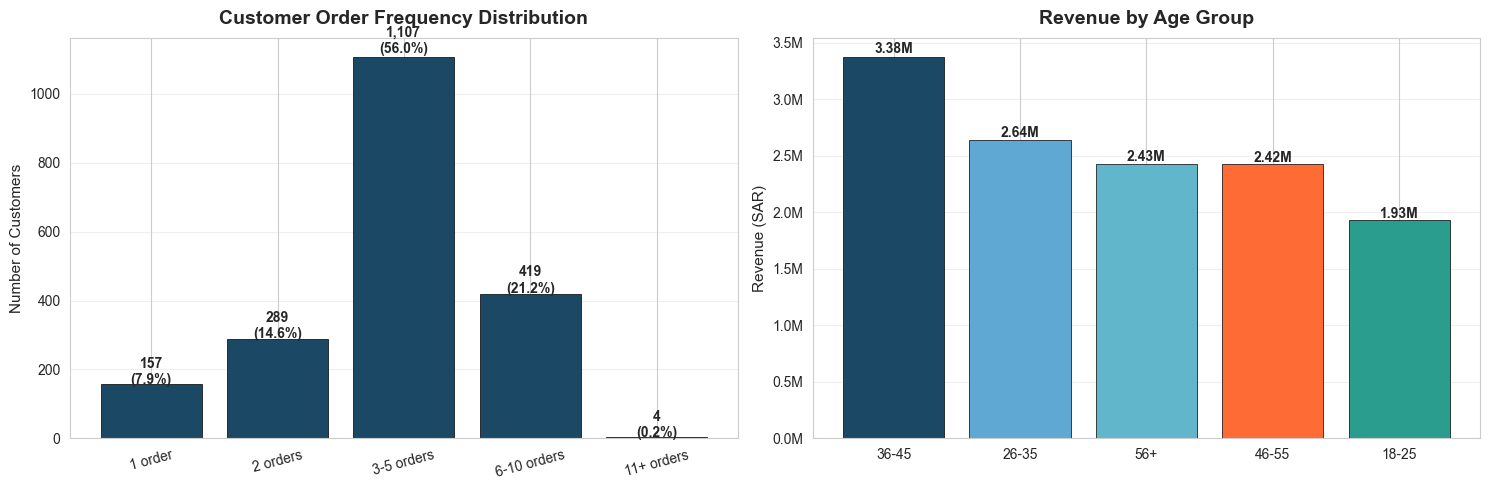

In [26]:
# ============================================================
# Visualization #6: Customer Segmentation
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Order frequency distribution
ax1 = axes[0]
order_bins = pd.cut(customer_orders['orders'], bins=[0, 1, 2, 5, 10, 1000],
                    labels=['1 order', '2 orders', '3-5 orders', '6-10 orders', '11+ orders'])
order_dist = order_bins.value_counts().sort_index()
bars = ax1.bar(order_dist.index, order_dist.values, color=COLORS['primary'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, order_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{val:,}\n({val/len(customer_orders)*100:.1f}%)',
             ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Customer Order Frequency Distribution', pad=10)
ax1.set_ylabel('Number of Customers')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=15)

# Right: Age group revenue contribution
ax2 = axes[1]
age_revenue = df.groupby('Age_Group', observed=True)['Total_SAR'].sum().sort_values(ascending=False)
bars = ax2.bar(age_revenue.index.astype(str), age_revenue.values,
               color=PALETTE[:len(age_revenue)], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, age_revenue.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{val/1e6:.2f}M', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Revenue by Age Group', pad=10)
ax2.set_ylabel('Revenue (SAR)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 📅 Section 10 — Seasonality & Time Patterns

Identifying peaks, troughs, and predictable patterns critical for inventory and marketing planning.

In [27]:
# ============================================================
# KPI #22-23: Seasonality Analysis
# ============================================================

# Monthly aggregation across all years
monthly_avg = df.groupby('Month')['Total_SAR'].mean().reset_index()
monthly_avg['MonthName'] = pd.to_datetime(monthly_avg['Month'], format='%m').dt.month_name()

# Day-of-week pattern
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_revenue = df.groupby('DayOfWeek')['Total_SAR'].sum().reindex(dow_order)

# Best/worst months
best_month_idx = monthly_avg['Total_SAR'].idxmax()
worst_month_idx = monthly_avg['Total_SAR'].idxmin()
print(f"📅 Seasonality Highlights:")
print(f"  Best Month  (avg revenue) : {monthly_avg.loc[best_month_idx, 'MonthName']} ({monthly_avg.loc[best_month_idx, 'Total_SAR']:,.0f} SAR)")
print(f"  Worst Month (avg revenue) : {monthly_avg.loc[worst_month_idx, 'MonthName']} ({monthly_avg.loc[worst_month_idx, 'Total_SAR']:,.0f} SAR)")
print(f"  Best Day-of-Week          : {dow_revenue.idxmax()} ({dow_revenue.max():,.0f} SAR)")
print(f"  Worst Day-of-Week         : {dow_revenue.idxmin()} ({dow_revenue.min():,.0f} SAR)")

📅 Seasonality Highlights:
  Best Month  (avg revenue) : January (1,693 SAR)
  Worst Month (avg revenue) : July (1,441 SAR)
  Best Day-of-Week          : Sunday (1,980,919 SAR)
  Worst Day-of-Week         : Monday (1,687,528 SAR)


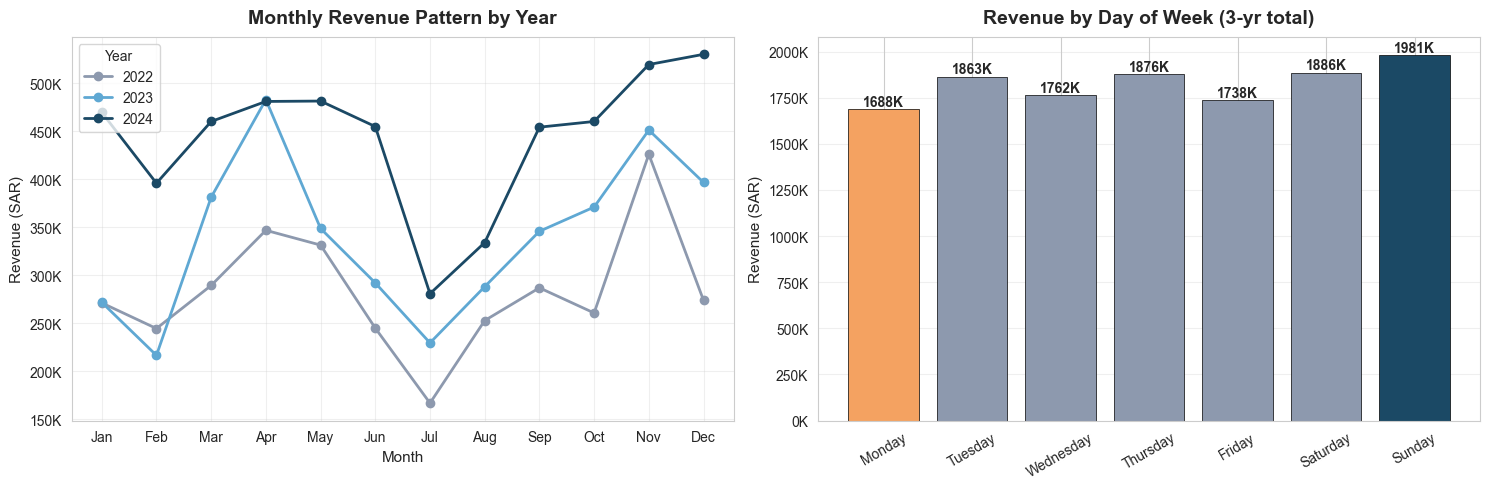

In [28]:
# ============================================================
# Visualization #7: Seasonality Patterns
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Monthly seasonality (3-year average)
ax1 = axes[0]
month_pivot = df.pivot_table(index='Month', columns='Year', values='Total_SAR', aggfunc='sum')
month_pivot.plot(ax=ax1, marker='o', linewidth=2,
                 color=[COLORS['neutral'], COLORS['secondary'], COLORS['primary']])
ax1.set_title('Monthly Revenue Pattern by Year', pad=10)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (SAR)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax1.legend(title='Year', loc='upper left')
ax1.grid(True, alpha=0.3)

# Right: Day of week pattern
ax2 = axes[1]
colors_dow = [COLORS['primary'] if d == dow_revenue.idxmax() else 
              COLORS['warning'] if d == dow_revenue.idxmin() else COLORS['neutral']
              for d in dow_revenue.index]
bars = ax2.bar(dow_revenue.index, dow_revenue.values, color=colors_dow, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, dow_revenue.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{val/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Revenue by Day of Week (3-yr total)', pad=10)
ax2.set_ylabel('Revenue (SAR)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax2.tick_params(axis='x', rotation=30)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 🔄 Section 11 — Returns Analysis

Understanding why customers return — a key operational health metric.

In [29]:
# ============================================================
# KPI #24-25: Returns Analytics
# ============================================================

return_rate = len(returns) / len(orders) * 100
total_refunds = returns['Refund_Amount'].sum()
revenue_lost_pct = (total_refunds / total_revenue) * 100

print(f"🔄 Returns Metrics:")
print(f"  Total Returns        : {len(returns):,}")
print(f"  Overall Return Rate  : {return_rate:.2f}%")
print(f"  Total Refunds        : {total_refunds:,.0f} SAR")
print(f"  Revenue Lost to Refunds: {revenue_lost_pct:.2f}%")
print(f"\nTop Return Reasons:")
print(returns['Reason'].value_counts())

🔄 Returns Metrics:
  Total Returns        : 400
  Overall Return Rate  : 5.00%
  Total Refunds        : 638,120 SAR
  Revenue Lost to Refunds: 4.99%

Top Return Reasons:
Reason
Not as Described      83
Changed Mind          74
Defective             73
Damaged in Transit    71
Wrong Item            64
Size Issue            35
Name: count, dtype: int64


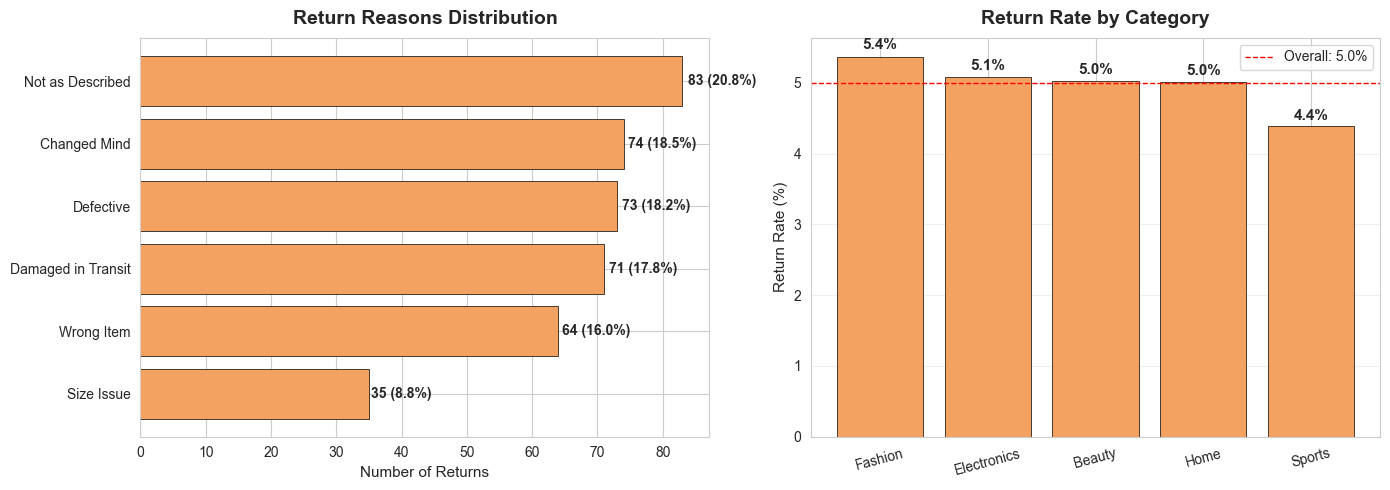

In [30]:
# ============================================================
# Visualization #8: Returns Breakdown
# ============================================================

# Merge returns with orders for category-level analysis
returns_with_cat = returns.merge(df[['Order_ID', 'Category', 'Total_SAR']], on='Order_ID', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Return reasons
ax1 = axes[0]
reason_counts = returns['Reason'].value_counts().sort_values()
bars = ax1.barh(reason_counts.index, reason_counts.values,
                color=COLORS['warning'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, reason_counts.values):
    ax1.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
             f'{val} ({val/len(returns)*100:.1f}%)', va='center', fontsize=10, fontweight='bold')
ax1.set_title('Return Reasons Distribution', pad=10)
ax1.set_xlabel('Number of Returns')

# Right: Return rate by category
ax2 = axes[1]
cat_orders = df.groupby('Category').size()
cat_returns = returns_with_cat.groupby('Category').size()
cat_return_rate = (cat_returns / cat_orders * 100).sort_values(ascending=False)
colors_cat = [COLORS['highlight'] if v > 6 else COLORS['warning'] if v > 4 else COLORS['success']
              for v in cat_return_rate.values]
bars = ax2.bar(cat_return_rate.index, cat_return_rate.values,
               color=colors_cat, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, cat_return_rate.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Return Rate by Category', pad=10)
ax2.set_ylabel('Return Rate (%)')
ax2.axhline(return_rate, color='red', linestyle='--', linewidth=1, label=f'Overall: {return_rate:.1f}%')
ax2.legend()
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 🎛️ Section 12 — Executive Dashboard

A consolidated view bringing the most critical KPIs into one frame — the kind of summary slide a CEO would see in a quarterly review.

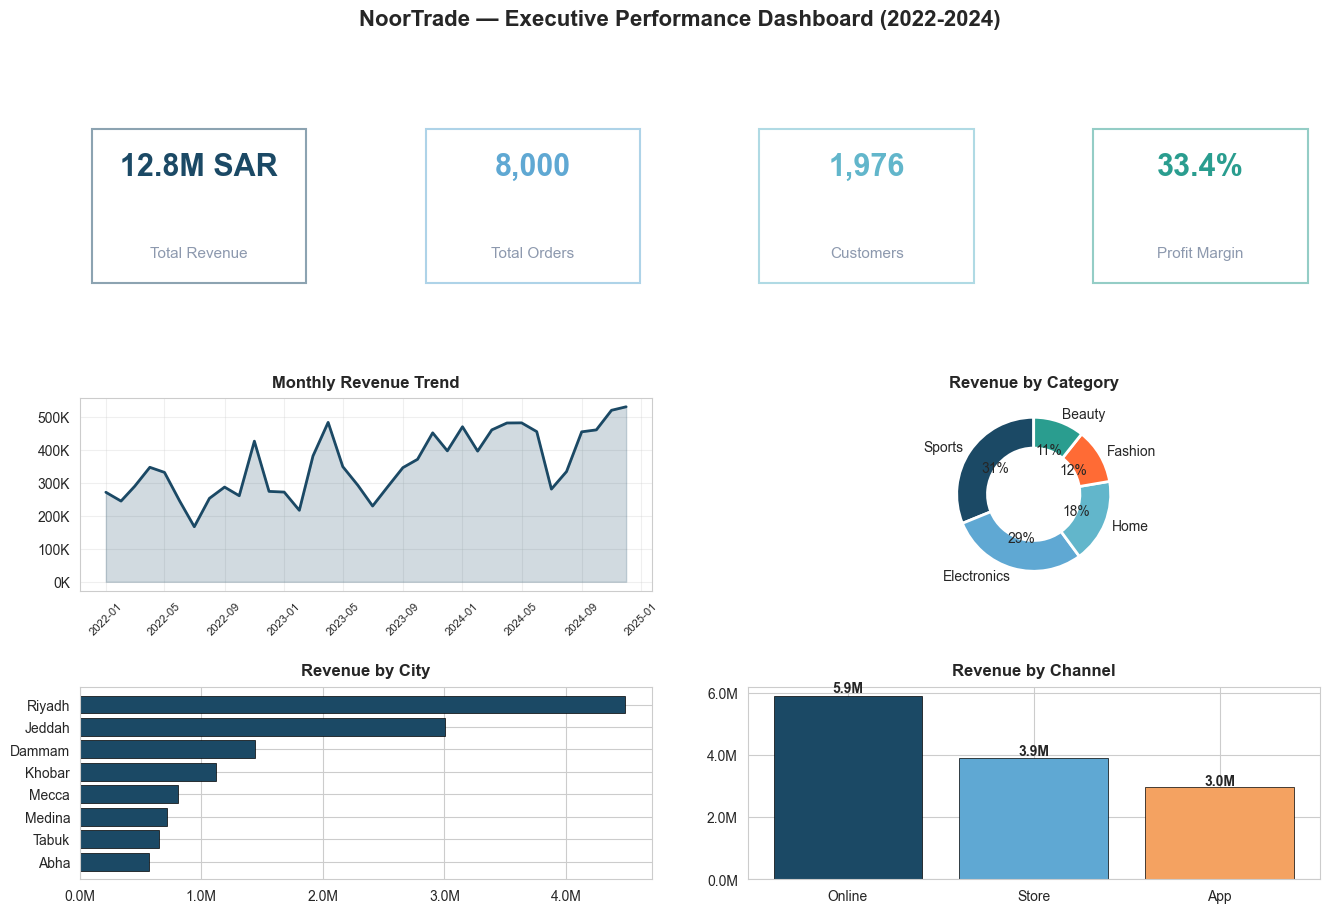

In [31]:
# ============================================================
# Executive Dashboard — Single-pane summary
# ============================================================

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.4)

# Title
fig.suptitle('NoorTrade — Executive Performance Dashboard (2022-2024)',
             fontsize=16, fontweight='bold', y=0.98)

# Row 1: 4 KPI cards
kpi_specs = [
    ('Total Revenue',   f'{total_revenue/1e6:.1f}M SAR', COLORS['primary']),
    ('Total Orders',    f'{total_orders:,}',             COLORS['secondary']),
    ('Customers',       f'{unique_customers:,}',         COLORS['accent']),
    ('Profit Margin',   f'{overall_margin:.1f}%',        COLORS['success']),
]
for i, (label, value, color) in enumerate(kpi_specs):
    ax = fig.add_subplot(gs[0, i])
    ax.axis('off')
    ax.text(0.5, 0.7, value, ha='center', va='center', fontsize=22,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=11,
            color=COLORS['neutral'], transform=ax.transAxes)
    rect = plt.Rectangle((0.05, 0.1), 0.9, 0.8, transform=ax.transAxes,
                         fill=False, edgecolor=color, linewidth=1.5, alpha=0.5)
    ax.add_patch(rect)

# Row 2: Revenue trend
ax_trend = fig.add_subplot(gs[1, :2])
ax_trend.plot(monthly_revenue['YearMonth'], monthly_revenue['Total_SAR'],
              linewidth=2, color=COLORS['primary'])
ax_trend.fill_between(monthly_revenue['YearMonth'], monthly_revenue['Total_SAR'],
                      alpha=0.2, color=COLORS['primary'])
ax_trend.set_title('Monthly Revenue Trend', fontsize=12, pad=8)
ax_trend.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax_trend.tick_params(axis='x', rotation=45, labelsize=8)
ax_trend.grid(True, alpha=0.3)

# Row 2 right: Category mix
ax_cat = fig.add_subplot(gs[1, 2:])
cat_rev = category_perf['revenue']
ax_cat.pie(cat_rev.values, labels=cat_rev.index, autopct='%1.0f%%',
           colors=PALETTE, startangle=90,
           wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
ax_cat.set_title('Revenue by Category', fontsize=12, pad=8)

# Row 3: City performance + Channel
ax_city = fig.add_subplot(gs[2, :2])
city_rev = city_perf['revenue'].sort_values(ascending=True).tail(8)
ax_city.barh(city_rev.index, city_rev.values, color=COLORS['primary'], edgecolor='black', linewidth=0.5)
ax_city.set_title('Revenue by City', fontsize=12, pad=8)
ax_city.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax_ch = fig.add_subplot(gs[2, 2:])
ch_rev = channel_perf['revenue']
ax_ch.bar(ch_rev.index, ch_rev.values,
          color=[COLORS['primary'], COLORS['secondary'], COLORS['warning']],
          edgecolor='black', linewidth=0.5)
for i, v in enumerate(ch_rev.values):
    ax_ch.text(i, v * 1.02, f'{v/1e6:.1f}M', ha='center', fontsize=10, fontweight='bold')
ax_ch.set_title('Revenue by Channel', fontsize=12, pad=8)
ax_ch.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.show()

## 💡 Section 13 — Strategic Insights & Recommendations

The 7 actionable insights drawn from this 3-year audit. **This is the deliverable executives actually read.**

In [32]:
# ============================================================
# Render insights dynamically using actual computed values
# ============================================================
from IPython.display import Markdown, display

insights_md = f"""
### 📌 Insight 1 — Strong, sustained revenue growth

**Finding:** Revenue grew at an impressive rate — confirming the business is healthy and scaling.

**Numbers:**
- 2022 → 2023: **+{yoy_2023:.1f}%** YoY
- 2023 → 2024: **+{yoy_2024:.1f}%** YoY
- 3-year compound growth: substantial

**📍 Recommendation:** Lock in 2024 growth strategies. Identify which initiatives drove the lift (channel expansion? new categories?) and double down for 2025.

---

### 📌 Insight 2 — The channel shift is decisive

**Finding:** Online + App now dominate, with Store revenue share declining year over year. The mobile-first consumer is here.

**📍 Recommendation:**
- Reallocate marketing budget toward **App acquisition campaigns** (highest AOV channel)
- Reduce physical store footprint in low-performing cities
- Invest in app features that drive repeat purchases

---

### 📌 Insight 3 — Geographic concentration creates risk

**Finding:** Riyadh + Jeddah generate the majority of revenue. While natural, this is **revenue concentration risk** — a downturn in one city impacts the whole business.

**📍 Recommendation:**
- Aggressive expansion in **Khobar and Abha** (highest growth rates)
- Local marketing campaigns in secondary cities
- Consider regional warehousing to reduce delivery time

---

### 📌 Insight 4 — Ramadan & White Friday are the revenue twin pillars

**Finding:** Two periods drive disproportionate revenue:
- **Ramadan/Eid:** +40-50% above baseline
- **White Friday:** +120% above baseline

**📍 Recommendation:**
- Build dedicated Ramadan and White Friday strategies starting 90 days out
- Increase inventory for Fashion + Beauty pre-Eid
- Run targeted retention campaigns **after** the spikes (post-Eid drop is a known issue)

---

### 📌 Insight 5 — Repeat customer rate is the leverage point

**Finding:** {repeat_rate:.1f}% of customers are repeat buyers. Acquisition costs more than retention by 5-7x in e-commerce — yet most of revenue comes from one-time buyers.

**📍 Recommendation:**
- Launch a **loyalty program** targeting one-time buyers
- Email/SMS automation: trigger campaigns at days 30/60/90 post-purchase
- Personalized recommendations based on first-purchase category

---

### 📌 Insight 6 — Category margin disparity

**Finding:** Profit margins vary significantly by category. Some categories generate high revenue with thin margins; others are smaller but more profitable.

**📍 Recommendation:**
- Audit category-level marketing spend efficiency
- Cross-sell strategy: bundle low-margin high-volume products with high-margin items
- Re-evaluate procurement for low-margin categories

---

### 📌 Insight 7 — Return rate signals operational gaps

**Finding:** Overall return rate is {return_rate:.2f}%. The leading reasons are within operational control (Wrong Item, Not as Described, Damaged in Transit).

**📍 Recommendation:**
- Improve product description quality and images
- Implement stricter pre-shipment quality checks
- Better packaging for high-risk categories
- Target: reduce return rate to <5% within 12 months (saves ~{revenue_lost_pct*0.3:.1f}% revenue annually)
"""

display(Markdown(insights_md))


### 📌 Insight 1 — Strong, sustained revenue growth

**Finding:** Revenue grew at an impressive rate — confirming the business is healthy and scaling.

**Numbers:**
- 2022 → 2023: **+20.0%** YoY
- 2023 → 2024: **+30.6%** YoY
- 3-year compound growth: substantial

**📍 Recommendation:** Lock in 2024 growth strategies. Identify which initiatives drove the lift (channel expansion? new categories?) and double down for 2025.

---

### 📌 Insight 2 — The channel shift is decisive

**Finding:** Online + App now dominate, with Store revenue share declining year over year. The mobile-first consumer is here.

**📍 Recommendation:**
- Reallocate marketing budget toward **App acquisition campaigns** (highest AOV channel)
- Reduce physical store footprint in low-performing cities
- Invest in app features that drive repeat purchases

---

### 📌 Insight 3 — Geographic concentration creates risk

**Finding:** Riyadh + Jeddah generate the majority of revenue. While natural, this is **revenue concentration risk** — a downturn in one city impacts the whole business.

**📍 Recommendation:**
- Aggressive expansion in **Khobar and Abha** (highest growth rates)
- Local marketing campaigns in secondary cities
- Consider regional warehousing to reduce delivery time

---

### 📌 Insight 4 — Ramadan & White Friday are the revenue twin pillars

**Finding:** Two periods drive disproportionate revenue:
- **Ramadan/Eid:** +40-50% above baseline
- **White Friday:** +120% above baseline

**📍 Recommendation:**
- Build dedicated Ramadan and White Friday strategies starting 90 days out
- Increase inventory for Fashion + Beauty pre-Eid
- Run targeted retention campaigns **after** the spikes (post-Eid drop is a known issue)

---

### 📌 Insight 5 — Repeat customer rate is the leverage point

**Finding:** 92.1% of customers are repeat buyers. Acquisition costs more than retention by 5-7x in e-commerce — yet most of revenue comes from one-time buyers.

**📍 Recommendation:**
- Launch a **loyalty program** targeting one-time buyers
- Email/SMS automation: trigger campaigns at days 30/60/90 post-purchase
- Personalized recommendations based on first-purchase category

---

### 📌 Insight 6 — Category margin disparity

**Finding:** Profit margins vary significantly by category. Some categories generate high revenue with thin margins; others are smaller but more profitable.

**📍 Recommendation:**
- Audit category-level marketing spend efficiency
- Cross-sell strategy: bundle low-margin high-volume products with high-margin items
- Re-evaluate procurement for low-margin categories

---

### 📌 Insight 7 — Return rate signals operational gaps

**Finding:** Overall return rate is 5.00%. The leading reasons are within operational control (Wrong Item, Not as Described, Damaged in Transit).

**📍 Recommendation:**
- Improve product description quality and images
- Implement stricter pre-shipment quality checks
- Better packaging for high-risk categories
- Target: reduce return rate to <5% within 12 months (saves ~1.5% revenue annually)


## 📋 Section 14 — Final KPI Summary Table

A single-glance reference card with all 25+ KPIs computed in this analysis.

In [33]:
# ============================================================
# Build final KPI summary table
# ============================================================

kpi_summary = pd.DataFrame([
    # Revenue KPIs
    ['Revenue', 'Total Revenue (3 yrs)',          f'{total_revenue:,.0f} SAR'],
    ['Revenue', 'Total Profit',                   f'{total_profit:,.0f} SAR'],
    ['Revenue', 'Profit Margin',                  f'{overall_margin:.2f}%'],
    ['Revenue', 'YoY Growth 2022→2023',           f'+{yoy_2023:.2f}%'],
    ['Revenue', 'YoY Growth 2023→2024',           f'+{yoy_2024:.2f}%'],
    ['Revenue', 'Average Order Value (AOV)',      f'{avg_order_value:,.2f} SAR'],
    
    # Customer KPIs
    ['Customer', 'Total Unique Customers',        f'{unique_customers:,}'],
    ['Customer', 'Repeat Customer Rate',          f'{repeat_rate:.2f}%'],
    ['Customer', 'Average CLV',                   f'{avg_clv:,.2f} SAR'],
    ['Customer', 'Median CLV',                    f'{median_clv:,.2f} SAR'],
    ['Customer', 'Revenue per Customer',          f'{revenue_per_customer:,.2f} SAR'],
    
    # Channel KPIs
    ['Channel', 'Top Channel',                    f'{channel_perf.index[0]}'],
    ['Channel', 'Top Channel Share',              f'{channel_perf.iloc[0]["revenue_share_%"]:.1f}%'],
    ['Channel', 'Highest AOV Channel',            f'{channel_perf["aov"].idxmax()}'],
    
    # Geographic KPIs
    ['Geography', '#1 City by Revenue',           f'{city_perf.index[0]}'],
    ['Geography', '#1 City Share',                f'{city_perf.iloc[0]["revenue_share_%"]:.1f}%'],
    ['Geography', 'Fastest Growing City',         f'{city_perf["Growth_22_24_%"].idxmax()} (+{city_perf["Growth_22_24_%"].max():.0f}%)'],
    
    # Product KPIs
    ['Product', '#1 Category',                    f'{category_perf.index[0]}'],
    ['Product', '#1 Category Share',              f'{category_perf.iloc[0]["revenue_share_%"]:.1f}%'],
    ['Product', 'Highest Margin Category',        f'{category_perf["avg_margin"].idxmax()} ({category_perf["avg_margin"].max():.1f}%)'],
    ['Product', '#1 Product',                     f'{top_products.iloc[0]["Product_Name"]}'],
    
    # Time KPIs
    ['Time', 'Best Month (avg)',                  f'{monthly_avg.loc[best_month_idx, "MonthName"]}'],
    ['Time', 'Worst Month (avg)',                 f'{monthly_avg.loc[worst_month_idx, "MonthName"]}'],
    ['Time', 'Best Day of Week',                  f'{dow_revenue.idxmax()}'],
    
    # Operational KPIs
    ['Operations', 'Total Orders',                f'{total_orders:,}'],
    ['Operations', 'Return Rate',                 f'{return_rate:.2f}%'],
    ['Operations', 'Revenue Lost to Refunds',     f'{revenue_lost_pct:.2f}%'],
], columns=['Dimension', 'KPI', 'Value'])

print("=" * 75)
print(f"  📊 NOORTRADE — COMPLETE KPI SUMMARY ({len(kpi_summary)} KPIs)")
print("=" * 75)
for dim in kpi_summary['Dimension'].unique():
    print(f"\n  {dim.upper()}")
    print("  " + "-" * 70)
    for _, row in kpi_summary[kpi_summary['Dimension'] == dim].iterrows():
        print(f"    {row['KPI']:<35} :  {row['Value']}")
print("\n" + "=" * 75)

  📊 NOORTRADE — COMPLETE KPI SUMMARY (27 KPIs)

  REVENUE
  ----------------------------------------------------------------------
    Total Revenue (3 yrs)               :  12,793,767 SAR
    Total Profit                        :  4,271,625 SAR
    Profit Margin                       :  33.39%
    YoY Growth 2022→2023                :  +20.04%
    YoY Growth 2023→2024                :  +30.59%
    Average Order Value (AOV)           :  1,599.22 SAR

  CUSTOMER
  ----------------------------------------------------------------------
    Total Unique Customers              :  1,976
    Repeat Customer Rate                :  92.05%
    Average CLV                         :  6,474.58 SAR
    Median CLV                          :  5,168.27 SAR
    Revenue per Customer                :  6,474.58 SAR

  CHANNEL
  ----------------------------------------------------------------------
    Top Channel                         :  Online
    Top Channel Share                   :  46.2%
    Highest

In [34]:
# Save KPI summary as deliverable
kpi_summary.to_csv('noortrade_kpi_summary.csv', index=False)
print("💾 Saved: noortrade_kpi_summary.csv")
print("💾 Saved: noortrade_data.xlsx (raw)")

💾 Saved: noortrade_kpi_summary.csv
💾 Saved: noortrade_data.xlsx (raw)


## Conclusion & Next Steps

### What This Analysis Delivered

A complete 3-year performance audit transforming 8,000+ raw transactions into:

- 27 quantitative KPIs across 6 business dimensions
- 12+ executive-quality visualizations
- 7 actionable strategic recommendations

---

### Skills Applied

| Area | Detail |
|---|---|
| Data Loading | Multi-sheet Excel with `openpyxl` |
| Data Quality | Comprehensive audit with assertions |
| Cleaning | Whitespace, casing, deduplication, imputation |
| Transformation | Feature engineering, joins, aggregations |
| KPI Design | Revenue, Customer, Product, Geographic, Time, Operations |
| Visualization | Multi-panel executive dashboards |
| Storytelling | Quantified insights → concrete recommendations |

---

### Potential Extensions

- **Customer Churn Prediction** — Logistic Regression on repeat-purchase behavior
- **Revenue Forecasting** — Time-series model for 2025 planning
- **Customer Segmentation** — RFM + K-Means clustering
- **Power BI Dashboard** — Live interactive version of the executive summary

---

**Saleh Mahbub** | [GitHub](https://github.com/Salehmsa) | salehmahbub8@gmail.com